<a href="https://colab.research.google.com/github/vcanio/MineriaDeDatos/blob/Vicente-Canio/Premier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Importación y Carga de Datos

In [24]:
# Importamos librerías esenciales para manipulación de datos (Pandas, Numpy)
# y visualización (Matplotlib, Seaborn).
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

# Ajustamos la visualización de Pandas para evitar que trunque las columnas o filas importantes
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100) # Es mejor poner un límite como 100 para no saturar la memoria visual

In [25]:
# Cargamos el dataset histórico de la Premier League
df = pd.read_csv("/content/epl_final.csv")

# Verificamos las dimensiones del dataset (cantidad de filas y columnas)
print(f"Dimensiones del dataset: {df.shape}")

Dimensiones del dataset: (9380, 22)


In [26]:
# Inspeccionamos las primeras y últimas filas para confirmar que los datos se cargaron correctamente
display(df.head())
display(df.tail())

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,17,8,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,17,12,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,6,16,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,6,13,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,17,12,8,6,6,4,21,20,1,3,0,0


,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
9375,2024/25,2025-05-04,Brentford,Man United,4,3,H,2,1,H,12,14,6,5,7,4,8,10,0,2,0,0
9376,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,5,13,2,5,1,4,15,10,2,1,0,0
9377,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,11,7,2,2,1,3,18,15,2,2,0,0
9378,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,17,11,7,2,3,6,10,11,2,2,0,0
9379,2024/25,2025-05-05,Crystal Palace,Nott'm Forest,1,1,D,0,0,D,20,12,3,4,7,4,9,15,3,8,0,0


# 2. Entendimiento Inicial de los Datos

In [27]:
# Revisamos los tipos de datos (strings, enteros, etc.) para saber si necesitamos conversiones
df.dtypes

,0
Season,object
MatchDate,object
HomeTeam,object
AwayTeam,object
FullTimeHomeGoals,int64
FullTimeAwayGoals,int64
FullTimeResult,object
HalfTimeHomeGoals,int64
HalfTimeAwayGoals,int64
HalfTimeResult,object


In [28]:
# Buscamos si existen valores nulos que debamos imputar o eliminar
df.isnull().sum()

,0
Season,0
MatchDate,0
HomeTeam,0
AwayTeam,0
FullTimeHomeGoals,0
FullTimeAwayGoals,0
FullTimeResult,0
HalfTimeHomeGoals,0
HalfTimeAwayGoals,0
HalfTimeResult,0


In [29]:
# Resumen estadístico de las variables numéricas (promedios, mínimos, máximos)
df.describe()

# --- Análisis de Categorías ---

# Vemos la distribución de partidos jugados como local por cada equipo
cant_team_df = df['HomeTeam'].value_counts()
print("Top equipos jugando de local:")
print(cant_team_df.head())
print(f"Total de equipos únicos: {cant_team_df.count()}\n")

# Analizamos la distribución de los resultados a tiempo completo y al medio tiempo
cant_full_time_df = df['FullTimeResult'].value_counts()
cant_half_time_df = df['HalfTimeResult'].value_counts()
print(f"Resultados Finales:\n{cant_full_time_df}\n")
print(f"Resultados Medio Tiempo:\n{cant_half_time_df}")

Top equipos jugando de local:
HomeTeam
Everton       471
Chelsea       469
Tottenham     469
Man United    469
Arsenal       468
Name: count, dtype: int64
Total de equipos únicos: 46

Resultados Finales:
FullTimeResult
H    4299
A    2768
D    2313
Name: count, dtype: int64

Resultados Medio Tiempo:
HalfTimeResult
D    3840
H    3290
A    2250
Name: count, dtype: int64


# Mapeo de Datos

* **Season**:
    * *Tipo Pandas*: `object`
    * *Tipo Estadístico*: Categórico Ordinal
    * *Descripción*: Representa la temporada. Tiene un orden cronológico natural.
* **MatchDate**:
    * *Tipo Pandas*: `object`
    * *Tipo Estadístico*: Temporal / Razón
    * *Descripción*: Fecha exacta del partido.
* **HomeTeam** / **AwayTeam**:
    * *Tipo Pandas*: `object`
    * *Tipo Estadístico*: Categórico Nominal
    * *Descripción*: Nombres de los equipos. No existe un orden jerárquico entre ellos.
* **FullTimeResult** / **HalfTimeResult**:
    * *Tipo Pandas*: `object`
    * *Tipo Estadístico*: Categórico Nominal
    * *Descripción*: Clases mutuamente excluyentes (H, A, D).
* **FullTimeResult_Encoded**:
    * *Tipo Pandas*: `int64`
    * *Tipo Estadístico*: Categórico Nominal (Codificado)
    * *Descripción*: Representación numérica generada por `LabelEncoder`.
* **FullTimeHomeGoals** / **FullTimeAwayGoals**:
    * *Tipo Pandas*: `int64`
    * *Tipo Estadístico*: Numérico Discreto
    * *Descripción*: Cantidad de goles marcados. Números enteros contables.
* **HomeShots** / **AwayShots** (y variables similares On Target, Corners, Fouls, Cards):
    * *Tipo Pandas*: `int64`
    * *Tipo Estadístico*: Numérico Discreto
    * *Descripción*: Conteos de eventos en el partido (tiros, faltas, tarjetas). Valores enteros contables.

# 3. Limpieza y Transformación

In [32]:
# --- 1. TRANSFORMACIÓN DE DATOS ---
# Convertimos la columna MatchDate (que actualmente es object/string) a tipo datetime
df['MatchDate'] = pd.to_datetime(df['MatchDate'])

# A partir de la fecha, podemos extraer el Año y el Mes como nuevas variables numéricas
# Esto nos puede servir para ver tendencias en distintos momentos del año
df['Year'] = df['MatchDate'].dt.year
df['Month'] = df['MatchDate'].dt.month

# Verificamos que el cambio se haya realizado
print("Nuevos tipos de datos para las fechas:")
print(df[['MatchDate', 'Year', 'Month']].dtypes)

Nuevos tipos de datos para las fechas:
MatchDate    datetime64[ns]
Year                  int32
Month                 int32
dtype: object


In [31]:
from sklearn.preprocessing import LabelEncoder

# Inicializamos el codificador para transformar variables categóricas (texto) a numéricas
label_encoder = LabelEncoder()

# Transformamos los resultados del partido (H, D, A) en números enteros
df['FullTimeResult_Encoded'] = label_encoder.fit_transform(df['FullTimeResult'])

# Guardamos e imprimimos el diccionario de mapeo para no olvidar qué número es qué resultado
print("Mapeo de FullTimeResult:")
for i, item in enumerate(label_encoder.classes_):
    print(f"{item} : {i}")

# Repetimos el proceso para los resultados del medio tiempo
df['HalfTimeResult_Encoded'] = label_encoder.fit_transform(df['HalfTimeResult'])

# Verificamos que las nuevas columnas codificadas se hayan integrado bien
display(df[['FullTimeResult', 'FullTimeResult_Encoded', 'HalfTimeResult', 'HalfTimeResult_Encoded']].head())

Mapeo de FullTimeResult:
A : 0
D : 1
H : 2


,FullTimeResult,FullTimeResult_Encoded,HalfTimeResult,HalfTimeResult_Encoded
0,H,2,H,2
1,H,2,H,2
2,A,0,D,1
3,D,1,A,0
4,H,2,H,2


# 4. Análisis Exploratorio de Datos

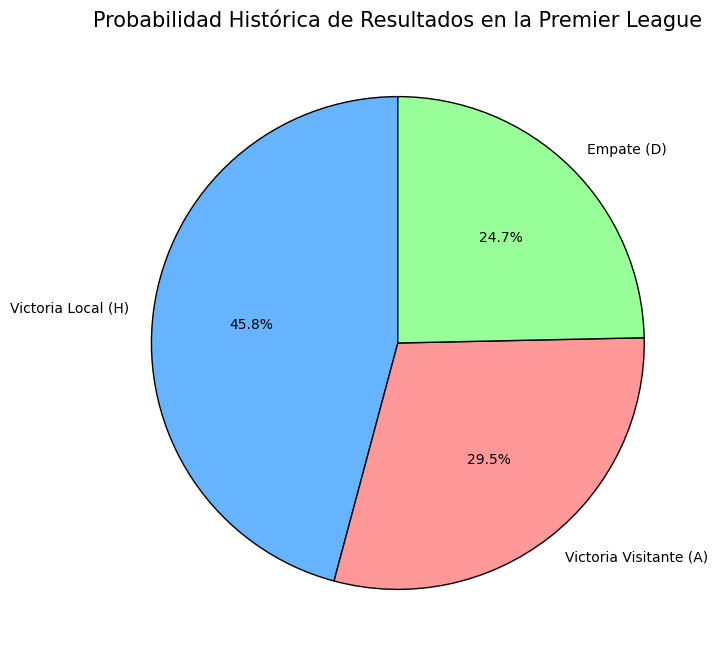

In [46]:
# --- Proporción de Resultados Finales ---
plt.figure(figsize=(8, 8))

# Contamos cuántas veces ocurrió cada resultado
conteo_resultados = df['FullTimeResult'].value_counts()

# Nombres más claros para la leyenda
etiquetas = ['Victoria Local (H)', 'Victoria Visitante (A)', 'Empate (D)']
colores = ['#66b3ff', '#ff9999', '#99ff99'] # Colores amigables a la vista

# Creamos el gráfico de pastel
plt.pie(conteo_resultados, labels=etiquetas, autopct='%1.1f%%',
        startangle=90, colors=colores, wedgeprops={'edgecolor': 'black'})

plt.title('Probabilidad Histórica de Resultados en la Premier League', fontsize=15)
plt.show()

# Interpretación: Este gráfico permite ver de un solo vistazo el peso real
# de la localía. Casi la mitad de los partidos (aprox. 45-46%) los gana el local.

/tmp/ipykernel_31357/178284756.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=cant_full_time_df.index, y=cant_full_time_df.values, palette='viridis')


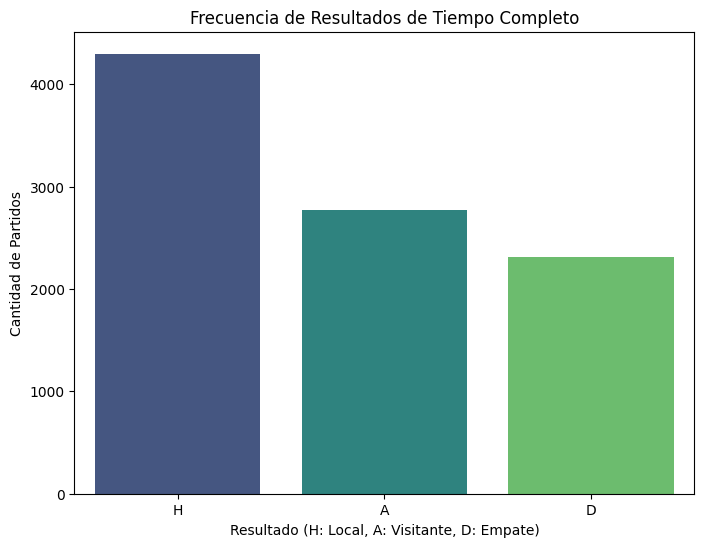

In [59]:
# Visualizamos la ventaja de la localía: comparamos victorias locales (H), visitantes (A) y empates (D)
plt.figure(figsize=(8, 6))
sb.barplot(x=cant_full_time_df.index, y=cant_full_time_df.values, palette='viridis')
plt.title('Frecuencia de Resultados de Tiempo Completo')
plt.xlabel('Resultado (H: Local, A: Visitante, D: Empate)')
plt.ylabel('Cantidad de Partidos')
plt.show()

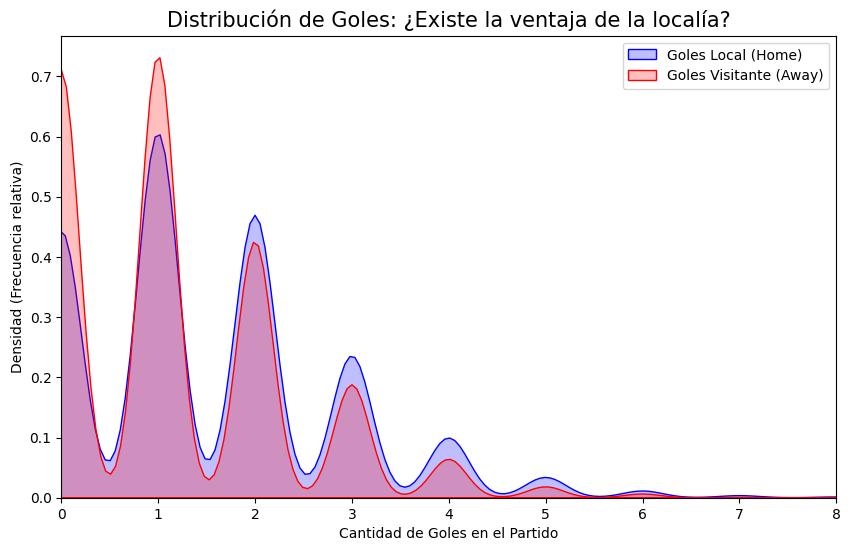

In [42]:
# --- Distribución de Goles (Local vs Visitante) ---
plt.figure(figsize=(10, 6))

# Usamos KDE (Kernel Density Estimate) para ver la forma de la distribución suave
sb.kdeplot(df['FullTimeHomeGoals'], fill=True, color="blue", label="Goles Local (Home)")
sb.kdeplot(df['FullTimeAwayGoals'], fill=True, color="red", label="Goles Visitante (Away)")

plt.title('Distribución de Goles: ¿Existe la ventaja de la localía?', fontsize=15)
plt.xlabel('Cantidad de Goles en el Partido')
plt.ylabel('Densidad (Frecuencia relativa)')
plt.xlim(0, 8) # Limitamos a 8 goles para que el gráfico no se deforme con valores extremos
plt.legend()
plt.show()


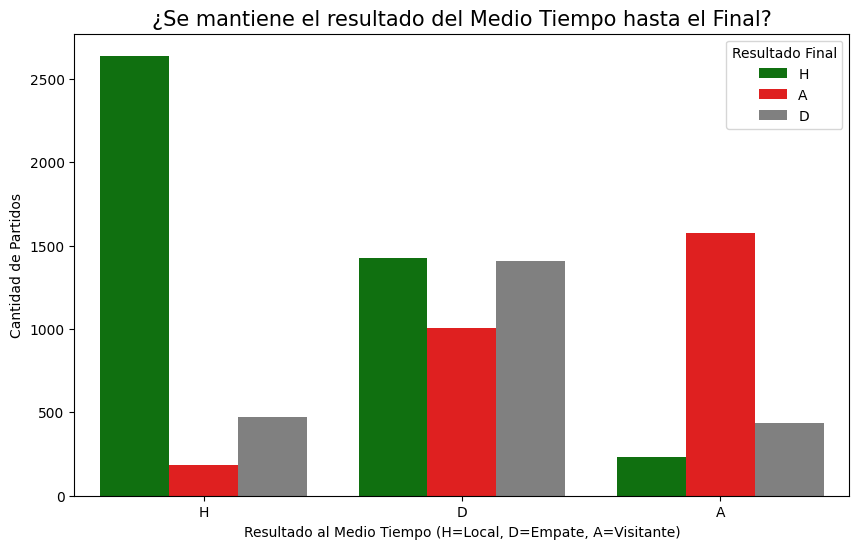

In [50]:
# --- Impacto del Medio Tiempo en el Resultado Final ---
plt.figure(figsize=(10, 6))

# Comparamos cómo iban al medio tiempo vs cómo terminaron
sb.countplot(data=df, x='HalfTimeResult', hue='FullTimeResult',
             palette={'H': 'green', 'D': 'gray', 'A': 'red'},
             order=['H', 'D', 'A'])

plt.title('¿Se mantiene el resultado del Medio Tiempo hasta el Final?', fontsize=15)
plt.xlabel('Resultado al Medio Tiempo (H=Local, D=Empate, A=Visitante)')
plt.ylabel('Cantidad de Partidos')
plt.legend(title='Resultado Final')
plt.show()


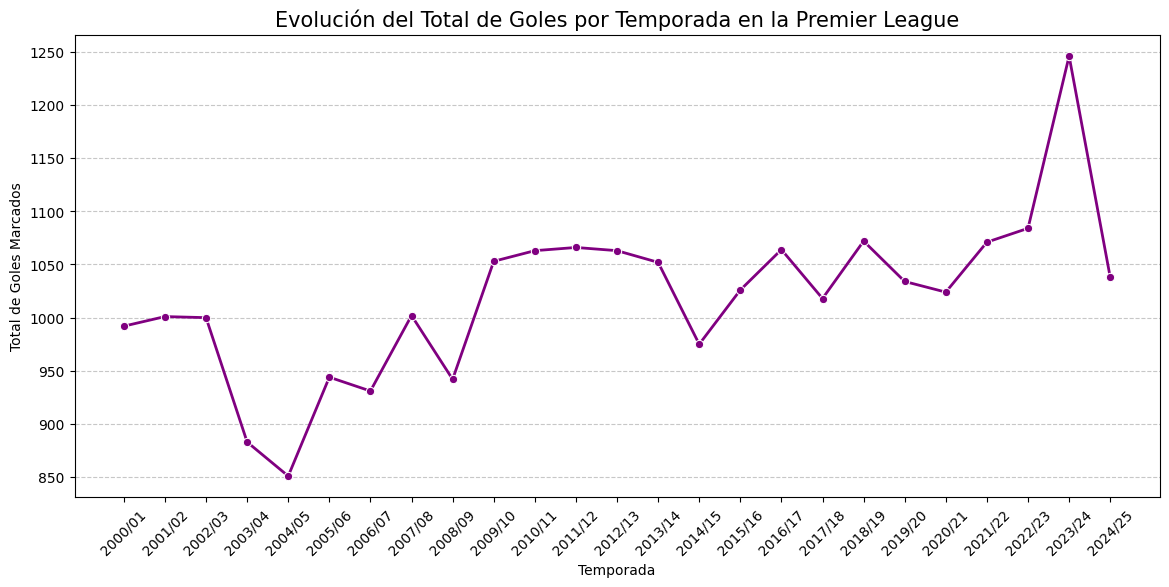

In [52]:
# --- Evolución de los Goles a lo largo de las Temporadas ---
plt.figure(figsize=(14, 6))

# Creamos una columna con el total de goles del partido
df['TotalMatchGoals'] = df['FullTimeHomeGoals'] + df['FullTimeAwayGoals']

# Agrupamos por temporada y sumamos todos los goles
goles_por_temporada = df.groupby('Season')['TotalMatchGoals'].sum()

# Gráfico de líneas con marcadores en los puntos
sb.lineplot(x=goles_por_temporada.index, y=goles_por_temporada.values,
            marker='o', linewidth=2, color='purple')

plt.title('Evolución del Total de Goles por Temporada en la Premier League', fontsize=15)
plt.xlabel('Temporada')
plt.ylabel('Total de Goles Marcados')
plt.xticks(rotation=45) # Rotamos los textos del eje X para que no se amontonen
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

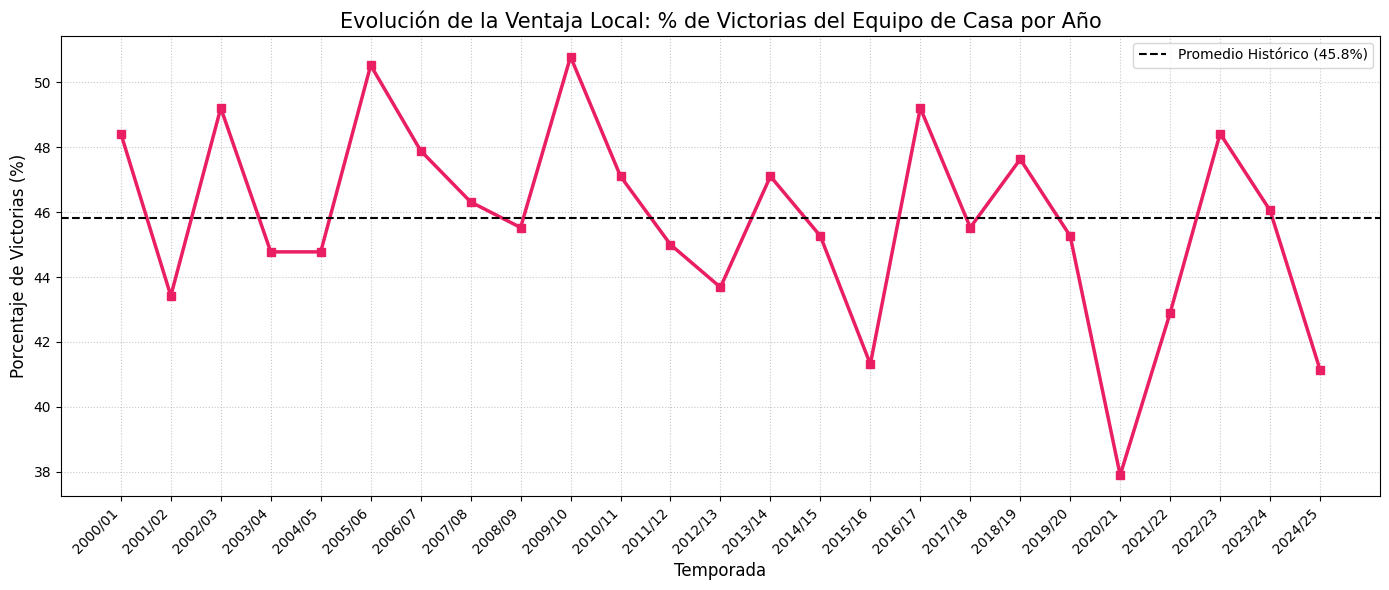

In [45]:
# -------------------------------------------------------------------
# Porcentaje de Victorias Locales por Temporada (Línea de Tendencia)
# -------------------------------------------------------------------
plt.figure(figsize=(14, 6))

# Calculamos el porcentaje de victorias locales por temporada usando crosstab
localia_tendencia = pd.crosstab(df['Season'], df['FullTimeResult'], normalize='index') * 100

# Extraemos solo la columna de victorias locales ('H')
porcentaje_local = localia_tendencia['H']

# Graficamos
plt.plot(porcentaje_local.index, porcentaje_local.values, marker='s', color='#e91e63', linewidth=2.5)

# Añadimos una línea horizontal con el promedio histórico para comparar
promedio_historico = porcentaje_local.mean()
plt.axhline(promedio_historico, color='black', linestyle='--', label=f'Promedio Histórico ({promedio_historico:.1f}%)')

plt.title("Evolución de la Ventaja Local: % de Victorias del Equipo de Casa por Año", fontsize=15)
plt.xlabel("Temporada", fontsize=12)
plt.ylabel("Porcentaje de Victorias (%)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

plt.savefig('evolucion_localia.png', dpi=100)
plt.show()

/tmp/ipykernel_31357/3412241738.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=top_goleadores.values, y=top_goleadores.index, palette='viridis')


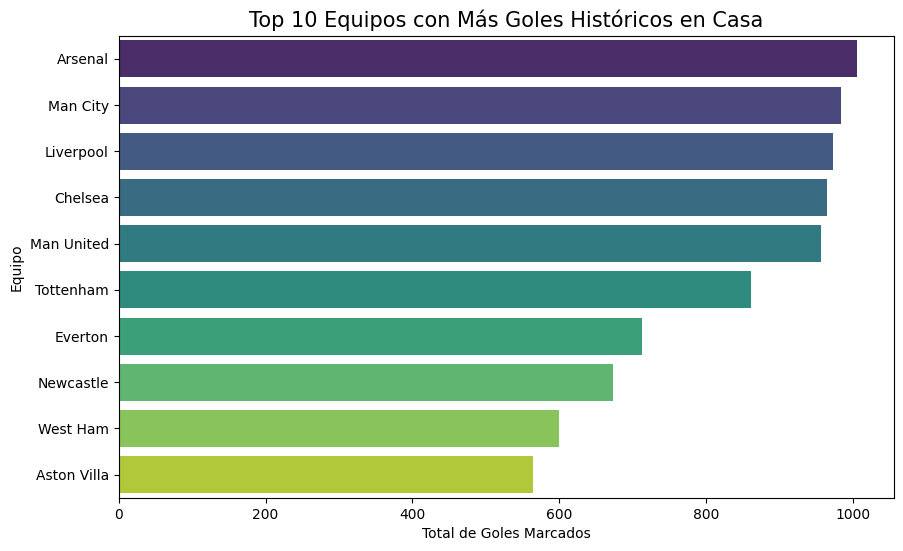

In [48]:
# --- Top 10 Equipos Goleadores en Casa ---
plt.figure(figsize=(10, 6))

# Agrupamos por equipo local, sumamos sus goles y nos quedamos con los 10 mejores
top_goleadores = df.groupby('HomeTeam')['FullTimeHomeGoals'].sum().sort_values(ascending=False).head(10)

# Gráfico de barras horizontal
sb.barplot(x=top_goleadores.values, y=top_goleadores.index, palette='viridis')

plt.title('Top 10 Equipos con Más Goles Históricos en Casa', fontsize=15)
plt.xlabel('Total de Goles Marcados')
plt.ylabel('Equipo')
plt.show()

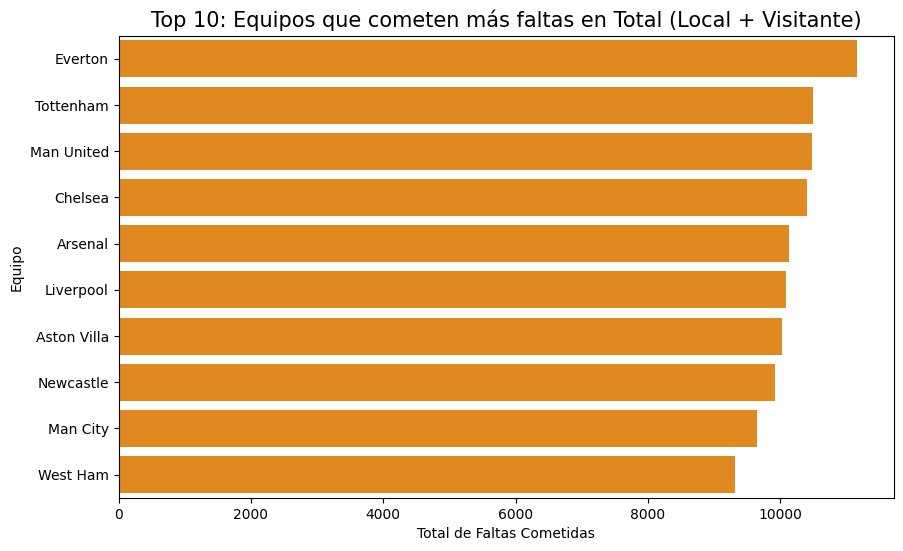

In [56]:
# --- Top 10 Equipos que más faltas cometen en total ---
plt.figure(figsize=(10, 6))

# 1. Calculamos las faltas cometidas como local
faltas_local = df.groupby('HomeTeam')['HomeFouls'].sum()

# 2. Calculamos las faltas cometidas como visitante
faltas_visitante = df.groupby('AwayTeam')['AwayFouls'].sum()

# 3. Sumamos ambas para tener el total real de faltas por equipo
total_faltas = (faltas_local + faltas_visitante).sort_values(ascending=False).head(10)

# Creamos el gráfico de barras horizontal (usamos un color naranja para indicar "precaución/faltas")
sb.barplot(x=total_faltas.values, y=total_faltas.index, color='darkorange')

plt.title('Top 10: Equipos que cometen más faltas en Total (Local + Visitante)', fontsize=15)
plt.xlabel('Total de Faltas Cometidas')
plt.ylabel('Equipo')
plt.show()

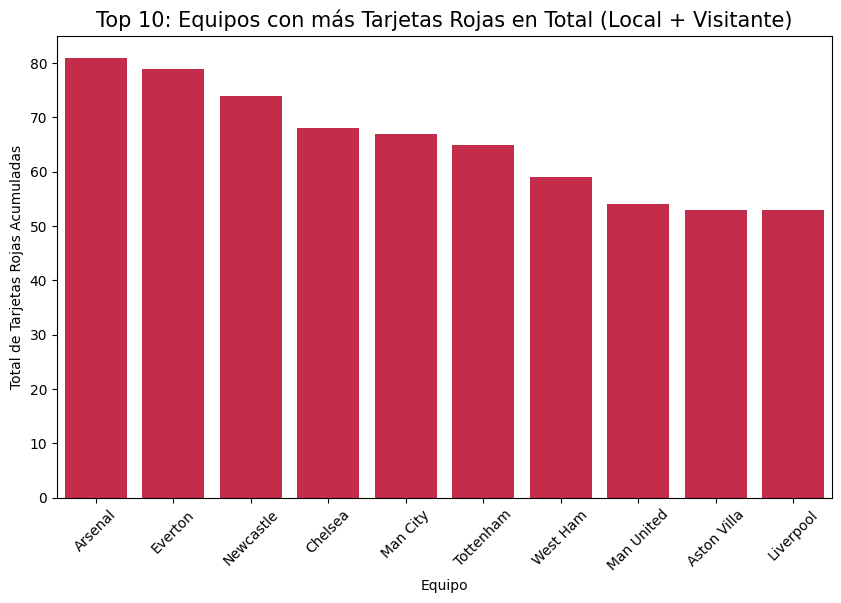

In [60]:
# --- Equipos con más Tarjetas Rojas en Total ---
plt.figure(figsize=(10, 6))

# 1. Calculamos las tarjetas rojas recibidas como local
rojas_local = df.groupby('HomeTeam')['HomeRedCards'].sum()

# 2. Calculamos las tarjetas rojas recibidas como visitante
rojas_visitante = df.groupby('AwayTeam')['AwayRedCards'].sum()

# 3. Sumamos ambas para tener el total real de rojas por equipo
total_rojas = (rojas_local + rojas_visitante).sort_values(ascending=False).head(10)

# Gráfico de barras (usamos color rojo/crimson para mayor contexto visual)
sb.barplot(x=total_rojas.index, y=total_rojas.values, color='crimson')

plt.title('Top 10: Equipos con más Tarjetas Rojas en Total (Local + Visitante)', fontsize=15)
plt.xlabel('Equipo')
plt.ylabel('Total de Tarjetas Rojas Acumuladas')
plt.xticks(rotation=45)
plt.show()


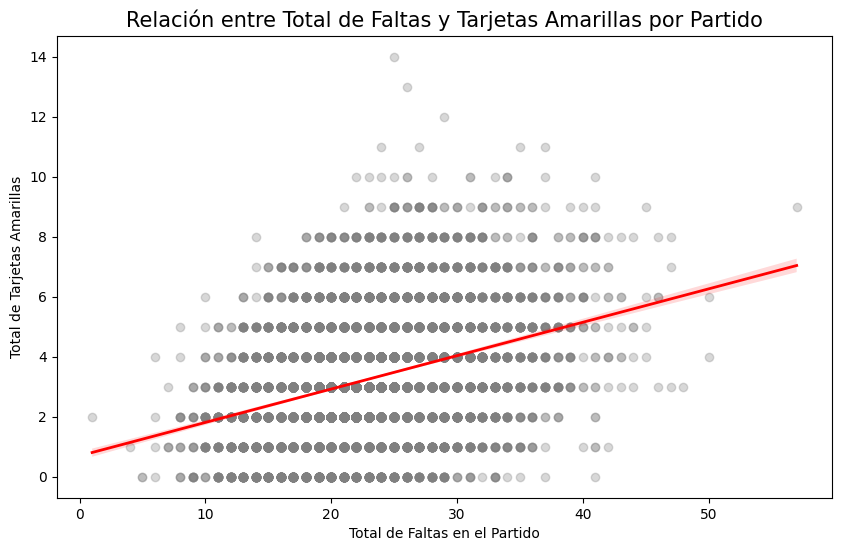

In [43]:
# --- Faltas vs Tarjetas Amarillas ---
plt.figure(figsize=(10, 6))

# Creamos columnas temporales para totalizar faltas y tarjetas en el partido
df['TotalFouls'] = df['HomeFouls'] + df['AwayFouls']
df['TotalYellows'] = df['HomeYellowCards'] + df['AwayYellowCards']

# Gráfico de regresión (scatter + línea de tendencia)
sb.regplot(x='TotalFouls', y='TotalYellows', data=df,
           scatter_kws={'alpha':0.3, 'color':'gray'}, # Puntos semi-transparentes
           line_kws={'color':'red', 'linewidth':2})   # Línea de tendencia roja

plt.title('Relación entre Total de Faltas y Tarjetas Amarillas por Partido', fontsize=15)
plt.xlabel('Total de Faltas en el Partido')
plt.ylabel('Total de Tarjetas Amarillas')
plt.show()


# 5. Detección de Outliers y Matriz de Correlación

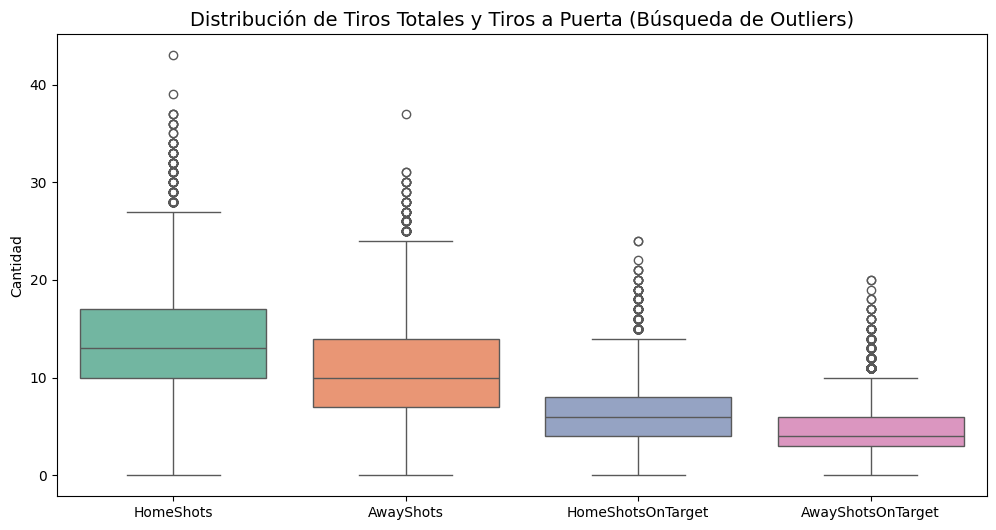

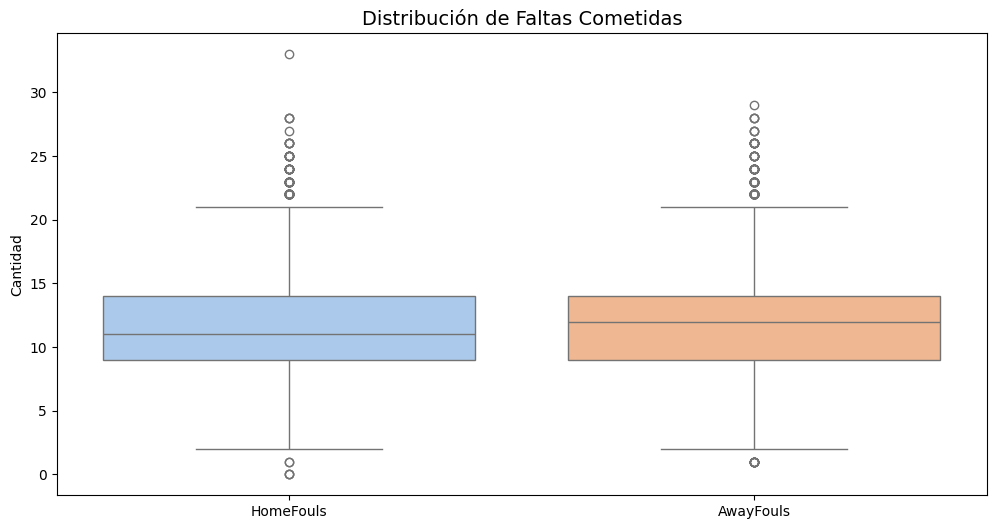

In [33]:
# --- ANÁLISIS DE DISTRIBUCIÓN Y OUTLIERS ---
# Seleccionamos algunas variables clave para ver su distribución mediante Boxplots
plt.figure(figsize=(12, 6))
sb.boxplot(data=df[['HomeShots', 'AwayShots', 'HomeShotsOnTarget', 'AwayShotsOnTarget']], palette='Set2')
plt.title('Distribución de Tiros Totales y Tiros a Puerta (Búsqueda de Outliers)', fontsize=14)
plt.ylabel('Cantidad')
plt.show()

plt.figure(figsize=(12, 6))
sb.boxplot(data=df[['HomeFouls', 'AwayFouls']], palette='pastel')
plt.title('Distribución de Faltas Cometidas', fontsize=14)
plt.ylabel('Cantidad')
plt.show()

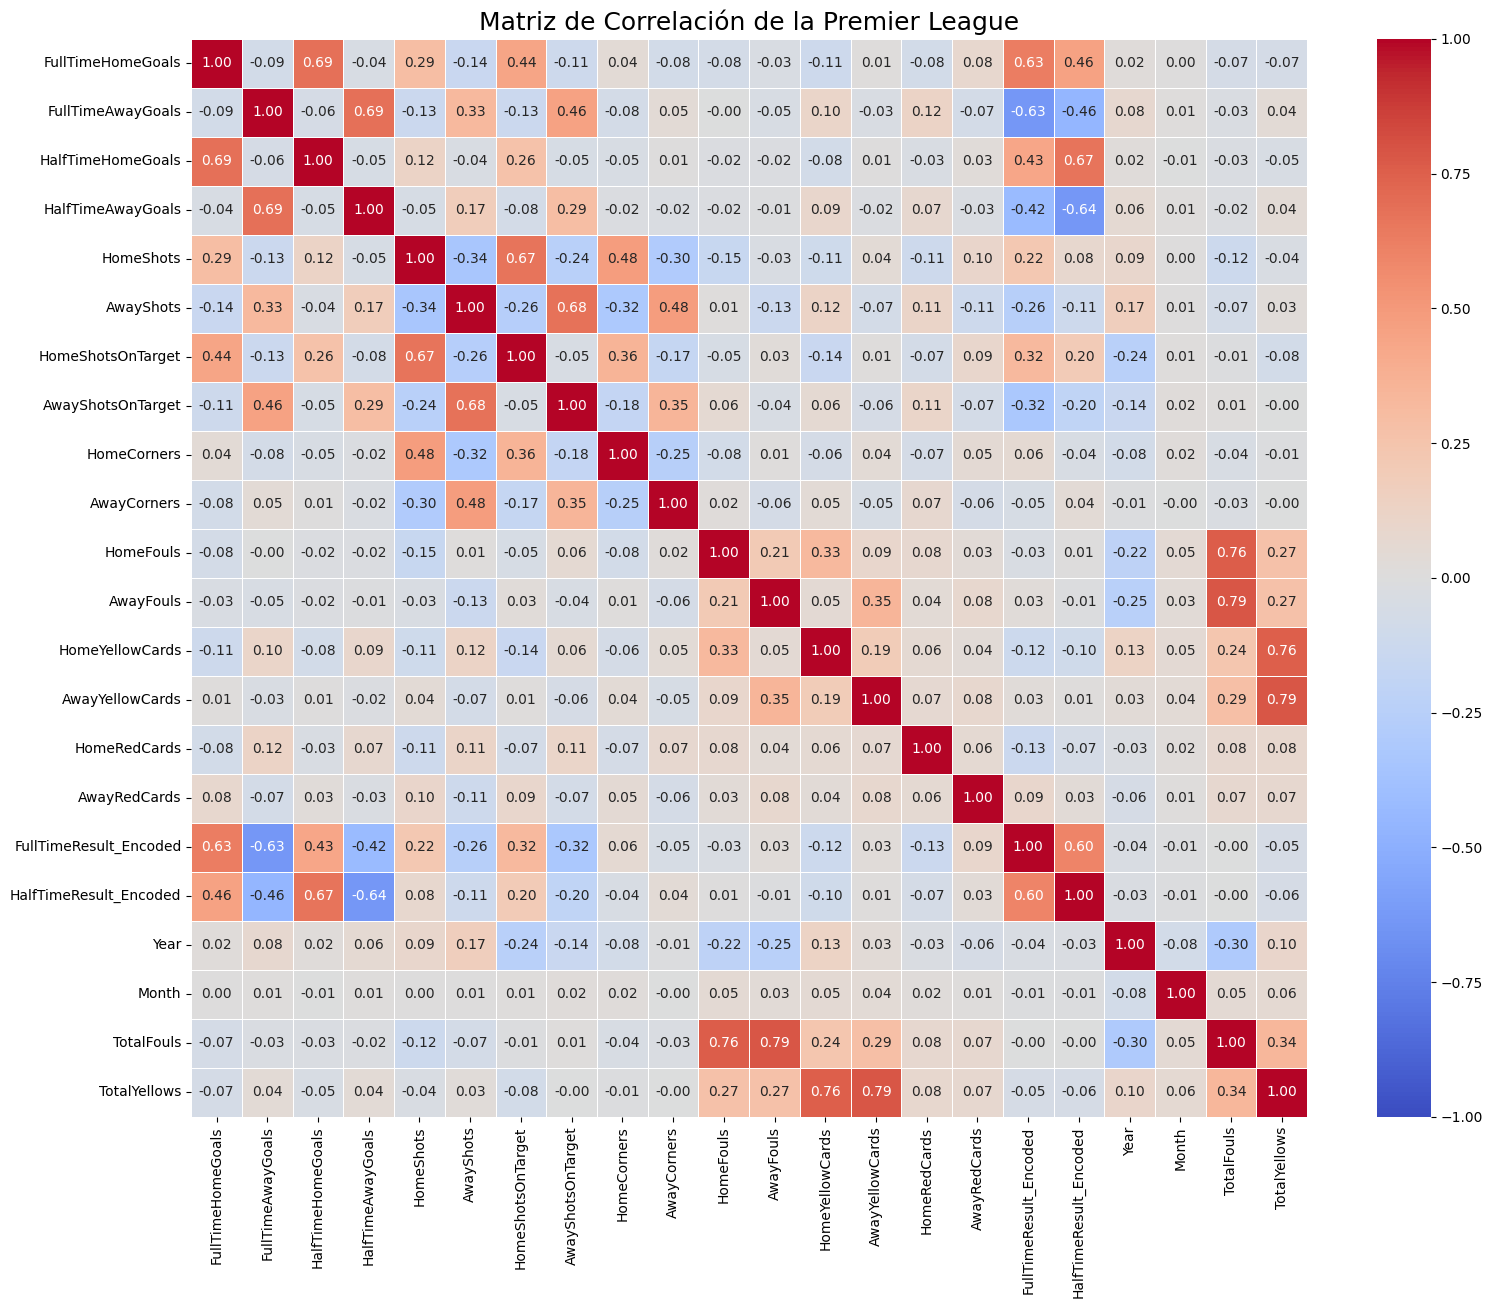

In [40]:
# --. ANÁLISIS DE CORRELACIÓN --
# El método .select_dtypes() filtra y deja fuera columnas de texto como HomeTeam o AwayTeam.
columnas_numericas = df.select_dtypes(include=[np.number])

# Calculamos la matriz de correlación
matriz_correlacion = columnas_numericas.corr()

# Creamos un Mapa de Calor (Heatmap) para visualizar las correlaciones
plt.figure(figsize=(18, 14)) # Tamaño grande porque hay muchas variables
sb.heatmap(matriz_correlacion,
           annot=True,        # Muestra los números en cada celda
           fmt=".2f",         # Redondea a 2 decimales
           cmap="coolwarm",   # Colores: rojo para correlación positiva, azul para negativa
           linewidths=0.5,    # Líneas separadoras
           vmin=-1, vmax=1)   # La correlación va de -1 a 1

plt.title("Matriz de Correlación de la Premier League", fontsize=18)
plt.show()

In [58]:
# Aislamos la variable objetivo codificada (FullTimeResult_Encoded)
# para ver qué variables numéricas impactan más en el resultado final del partido.
print("Correlación de las variables con el Resultado Final (FullTimeResult_Encoded):")
correlacion_resultado = matriz_correlacion['FullTimeResult_Encoded'].sort_values(ascending=False)
print(correlacion_resultado)

Correlación de las variables con el Resultado Final (FullTimeResult_Encoded):
FullTimeResult_Encoded    1.000000
FullTimeHomeGoals         0.630396
HalfTimeResult_Encoded    0.596965
HalfTimeHomeGoals         0.432693
HomeShotsOnTarget         0.323645
HomeShots                 0.224808
AwayRedCards              0.093704
HomeCorners               0.057625
AwayFouls                 0.030651
AwayYellowCards           0.029195
TotalFouls               -0.001559
Month                    -0.012818
HomeFouls                -0.034550
Year                     -0.037689
AwayCorners              -0.048674
TotalYellows             -0.054883
HomeYellowCards          -0.118126
HomeRedCards             -0.130704
AwayShots                -0.257528
AwayShotsOnTarget        -0.321245
HalfTimeAwayGoals        -0.422488
FullTimeAwayGoals        -0.634546
Name: FullTimeResult_Encoded, dtype: float64
